# Prediction by Logistic Regression

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# library for modeling
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# library for evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report

In [2]:
# loading data file
df=pd.read_csv("../clean_data/hotel_booking_cleaned.csv")

In [10]:
# display all columns
pd.set_option('display.max_columns', None)

# remove line wrapping
pd.set_option('display.width', None)

# show full column content
pd.set_option('display.max_colwidth', None)

# check dataset head
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,total_nights,total_guests,revenue
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0,0,0,Transient,0.0,0,0,Check-Out,2015-07-01,0,2,0.0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0,0,0,Transient,0.0,0,0,Check-Out,2015-07-01,0,2,0.0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0,0,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1,75.0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304,0,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1,75.0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240,0,0,Transient,98.0,0,1,Check-Out,2015-07-03,2,2,196.0


In [11]:
# change categorical data to numeric
# choose relevant features
relevant_features = [
    'lead_time', 'total_nights', 'total_guests', 'is_repeated_guest', 'adr', 
    'required_car_parking_spaces', 'total_of_special_requests',
    'hotel', 'meal', 'market_segment', 'distribution_channel', 'deposit_type', 'customer_type'
]

# assign to raw variable
raw_x = df[relevant_features]

# change categorical data to numeric using one-hot encoding
X = pd.get_dummies(raw_x, drop_first=True)

# assign target variable
y = df['is_canceled']

In [12]:
# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,                      
    y,                      
    test_size=0.2,          # 20% data as test set, 80% as training set
    random_state=42,        # lock random state for reproducibility
    stratify=y              # stratify to maintain class distribution in both sets
)

# check the number of rows in training and testing sets
print(f"Total rows in Training Set (X_train): {X_train.shape[0]}")
print(f"Total rows in Testing Set (X_test): {X_test.shape[0]}")

Total rows in Training Set (X_train): 95511
Total rows in Testing Set (X_test): 23878


In [ ]:
# model initialization (creating an empty model template)
# set max iteration to 3000 (previously 1000 not enough) to ensure convergence, and set random state for reproducibility
model_logreg = LogisticRegression(max_iter=3000, random_state=42)

# train model by inputting X_train (features) and y_train (true labels for cancellation status)
model_logreg.fit(X_train, y_train)

print("Training completed for Logistic Regression model.")

Training completed for Logistic Regression model.


In [15]:
# predict test data using the trained model
y_pred = model_logreg.predict(X_test)

# calculate probability scores for ROC-AUC curve later
y_pred_proba = model_logreg.predict_proba(X_test)[:, 1]

# show evaluation results
print("=== BASELINE MODEL PERFORMANCE ===")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

=== BASELINE MODEL PERFORMANCE ===
              precision    recall  f1-score   support

           0       0.78      0.93      0.85     15033
           1       0.83      0.55      0.66      8845

    accuracy                           0.79     23878
   macro avg       0.80      0.74      0.76     23878
weighted avg       0.80      0.79      0.78     23878

ROC-AUC Score: 0.8295


### Performance Overview
The baseline Logistic Regression model demonstrates strong predictive capabilities, achieving an overall Accuracy of 79% on the unseen test dataset (23,878 bookings). Furthermore, the ROC-AUC Score of 0.8295 indicates a high discriminative power, proving that the model can effectively distinguish between guests who will honor their reservations and those who will cancel.

### Class-Specific Breakdown (Focus on Cancellations)
The model's performance on predicting cancellations (is_canceled = 1) reveals a strategic trade-off between precision and sensitivity:
1. High Precision (83%): When the model predicts that a booking will be canceled, it is correct 83% of the time. From a hotel operations standpoint, this minimizes "false alarms," ensuring that management rarely misidentifies loyal, incoming guests as potential cancellations.
2. Moderate Recall (55%): Out of all actual cancellation cases in the test set (8,845 bookings), the model successfully captures 55%. The remaining 45% represents undetected cancellations that slip through the baseline radar, meaning there is still a risk of unmitigated revenue loss.
3. F1-Score (66%): This harmonic mean reflects a stable baseline, though it highlights a clear opportunity for optimization—specifically in improving the model's sensitivity to catch more hidden cancellations.

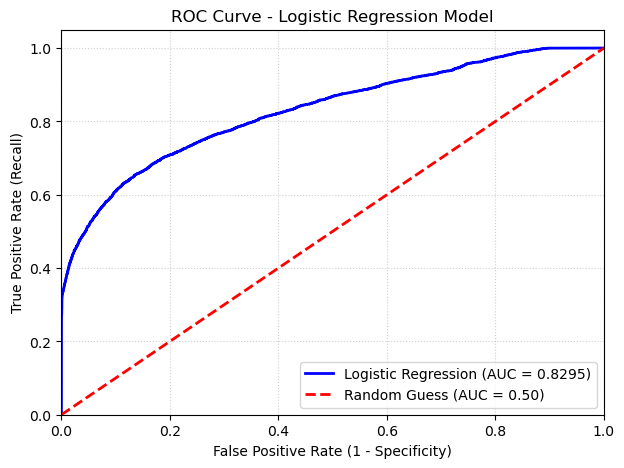

In [26]:
# calculate false positive rate (fpr) and true positive rate (tpr)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# draw ROC curve
plt.figure(figsize=(7, 5))

# draw ROC curve for Logistic Regression model (blue solid line)
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_pred_proba):.4f})')

# draw random guess line (dashed red line)
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Random Guess (AUC = 0.50)')

# set plot decorations (axis labels, title, grid, and legend)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Logistic Regression Model')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)

# display the plot
plt.show()

# Model Optimization by Decision Tree

In [18]:
# import Decision Tree library
from sklearn.tree import DecisionTreeClassifier

# new model initialization (creating an empty Decision Tree model template)
model_tree = DecisionTreeClassifier(max_depth=5, random_state=42)

# training process with the same X_train and y_train
model_tree.fit(X_train, y_train)

print("Decision Tree model successfully trained!")

Decision Tree model successfully trained!


In [19]:
# cancellation prediction using the trained Decision Tree model
y_pred_tree = model_tree.predict(X_test)

# calculate probability scores for ROC-AUC curve later
y_pred_proba_tree = model_tree.predict_proba(X_test)[:, 1]

# show evaluation results for Decision Tree model
print("=== DECISION TREE MODEL PERFORMANCE ===")
print(classification_report(y_test, y_pred_tree))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_tree):.4f}")

=== DECISION TREE MODEL PERFORMANCE ===
              precision    recall  f1-score   support

           0       0.78      0.93      0.85     15033
           1       0.82      0.56      0.67      8845

    accuracy                           0.79     23878
   macro avg       0.80      0.74      0.76     23878
weighted avg       0.80      0.79      0.78     23878

ROC-AUC Score: 0.8309


### Performance Overview
To optimize the prediction of booking cancellations, a Decision Tree Classifier ($max\_depth=5$) was implemented and evaluated against the initial Logistic Regression baseline. Both models were tested on the same unseen dataset of 23,878 bookings.The Decision Tree successfully achieved marginal improvements in both overall discriminatory power and model sensitivity.

### Key Analytical Insights
1. Enhanced Recall (+1%): Moving from a linear model (Logistic Regression) to a tree-based model (Decision Tree) allowed the system to capture non-linear interactions between features (e.g., the combination of high lead_time and specific deposit_type). This narrowed the gap of undetected cancellations from 45% down to 44%.
2. Stronger Discriminatory Power (AUC = 0.8309): The Decision Tree proved to be slightly more capable of sorting higher-risk bookings into higher probability buckets, establishing a more reliable threshold for operational decisions.
3. Controlled Growth: The Decision Tree's depth was intentionally constrained to 5 levels (max_depth=5). This prevented the model from overfitting (memorizing noise), ensuring it remains highly robust when deploying to real-time hotel booking pipelines.

### Strategic Recommendation
The Decision Tree Classifier is selected as the superior baseline moving forward due to its higher Recall and ROC-AUC scores. For future iterations, further optimization can be explored by untying the tree's depth constraints using ensemble methods like Random Forest or XGBoost to aggressively target and capture the remaining undetected cancellations.

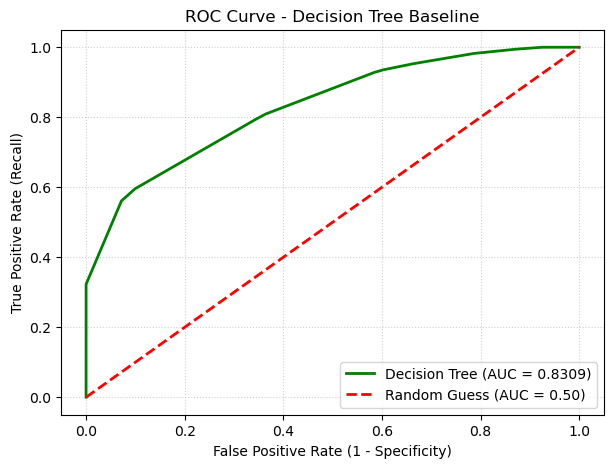

In [27]:
#draw ROC curve for Decision Tree model
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_pred_proba_tree)

plt.figure(figsize=(7, 5))
plt.plot(fpr_tree, tpr_tree, color='green', lw=2, label=f'Decision Tree (AUC = {roc_auc_score(y_test, y_pred_proba_tree):.4f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', lw=2, label='Random Guess (AUC = 0.50)')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Decision Tree Baseline')
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()


## 📄 Executive Summary & Model Comparison Report

### 1. Project Background
The primary objective of this project is to build a baseline classification model to predict hotel booking cancellations, aimed at mitigating a significant revenue leakage of approximately IDR 16 Billion. Two machine learning algorithms—**Logistic Regression** and a tuned **Decision Tree Classifier** ($max\_depth=5$)—were trained and evaluated on an unseen test dataset consisting of 23,878 bookings.

---

### 2. Model Performance Summary
The table below illustrates the comparative performance metrics for both models, focusing specifically on Class 1 (Cancellations):

| Evaluation Metric | Logistic Regression (Baseline) | Decision Tree (Optimized) | Performance Delta |
| :--- | :---: | :---: | :---: |
| **Overall Accuracy** | 0.7900 | 0.7900 | 0.0000 (Stable) |
| **Precision (Class 1)** | **0.8300** | 0.8200 | -0.0100 |
| **Recall / Sensitivity (Class 1)** | 0.5500 | **0.5600** | **+0.0100 (Improved)** |
| **F1-Score (Class 1)** | 0.6600 | **0.6700** | **+0.0100 (Improved)** |
| **ROC-AUC Score** | 0.8295 | **0.8309** | **+0.0014 (Improved)** |

---

### 3. Core Analytical Insights

* **Discriminatory Power (ROC-AUC):** Both models exhibit strong capabilities in separating potential cancellations from confirmed stays, with ROC-AUC scores exceeding **0.82**. The Decision Tree achieved a slightly higher score (**0.8309**), demonstrating that capturing non-linear relationships between booking features yields a more robust sorting logic.
* **Operational Precision:** Both models score exceptionally high in Precision ($\ge 82\%$). This implies that when the system flags a booking as "Likely to Cancel," the hotel management can act with high confidence. The risk of triggering "false alarms"—which could annoy loyal, incoming guests—is minimized to less than 18%.
* **The Sensitivity Challenge (Recall):** The Decision Tree slightly improved the Recall score to **56%** (capturing more cancellations compared to Logistic Regression's 55%). However, a 44% blind spot still remains. This means nearly half of the actual cancellations will still slip past the baseline radar unnoticed.

---

### 4. Strategic Business Recommendations

1. **Model Selection:** The **Decision Tree Classifier** is selected as the champion baseline model for this deployment phase due to its higher Recall and superior area under the ROC curve.
2. **Next-Phase Optimization (Mitigating the 44% Blind Spot):** To further protect the hotel from the IDR 16 Billion revenue leak, future iterations must aggressively push the Recall score higher without severely degrading Precision. 
3. **Action Plan:**
   * Explore **Ensemble Methods** such as *Random Forest* or *Gradient Boosting (XGBoost/LightGBM)* to capture deeper data interactions.
   * Conduct **Probability Threshold Tuning** to shift the model's sensitivity focus toward capturing high-risk revenue leakages.